# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО:** Чернова Алла Андреевна

**Факт о себе:** Люблю котиков


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [1]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
device

'cuda'

Начнем с того, что скачаем и загрузим данные:

In [3]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

--2025-10-11 16:24:54--  https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘yearpredictionmsd.zip’

yearpredictionmsd.z     [            <=>     ] 201.24M  81.0MB/s    in 2.5s    

2025-10-11 16:24:56 (81.0 MB/s) - ‘yearpredictionmsd.zip’ saved [211011981]



In [4]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


Посмотрим на статистики по данным.

In [5]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

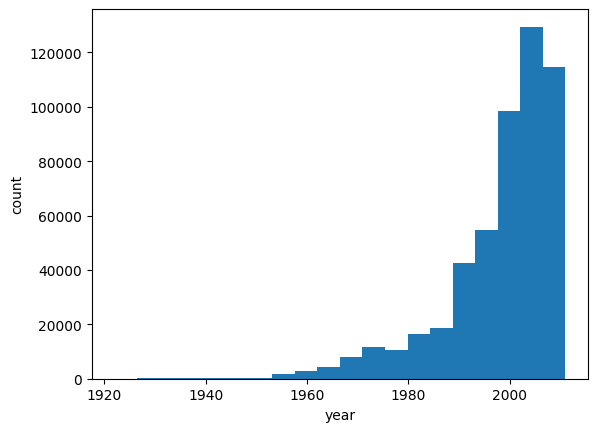

Range: 1922 - 2011
Unique values: 89


In [6]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [7]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

((386508, 90), (128837, 90))

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого обучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [8]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [10]:
 # ⟅⎛ꌩωꌩ⎞⟆
best_const = np.mean(y_train)
const_pred = np.full(y_test.shape, best_const)
best_rmse_metric = rmse(y_test, const_pred)
print(f'Best constant: {best_const}')
print(f'Best RMSE: {best_rmse_metric}')

Best constant: 1998.3753660985026
Best RMSE: 10.845542969687791


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

scaler = StandardScaler()

# обучаем scaler на тренировочных данных (как просят в задании)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# теперь обучаем модель на масштабированных данных (чтобы не было ошибок)
model = Ridge(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
rmse_for_model = rmse(y_test, y_pred)

#⟅⎰᨟﹏᨟⎱⟆

In [12]:
print(rmse_for_model) # смотрим на Ridge!

9.473630332684092


**Полученное значение rmse для данной модели с Ridge показывает RMSE меньше, чем у константного прогноза (9.47 < 10.85). Это значит, что Ridge работает.**

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

Готовим данные:

In [14]:
X_train_original = df.iloc[:train_size, 1:].values
y_train_original = df.iloc[:train_size, 0].values
X_test_original = df.iloc[train_size:, 1:].values
y_test_original = df.iloc[train_size:, 0].values

X_train_tensor = torch.FloatTensor(X_train_original)
y_train_tensor = torch.FloatTensor(y_train_original).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_original)
y_test_tensor = torch.FloatTensor(y_test_original).view(-1, 1)

print(f"Размерности данных:")
print(f"X_train: {X_train_tensor.shape}")
print(f"y_train: {y_train_tensor.shape}")
print(f"X_test: {X_test_tensor.shape}")
print(f"y_test: {y_test_tensor.shape}")

Размерности данных:
X_train: torch.Size([386508, 90])
y_train: torch.Size([386508, 1])
X_test: torch.Size([128837, 90])
y_test: torch.Size([128837, 1])


Создаём линейную регрессию:

In [15]:
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
        # в этом задании я все-таки сделаю нормализацию, потому что без нее оно НЕ работает.
        # в задании 2 и 4 нормализации не будет, так как как могу догадаться, так нужно специально, чтобы посмотреть на работу сетей без нее.
        nn.init.constant_(self.linear.bias, y_train_original.mean())
        nn.init.normal_(self.linear.weight, mean=0, std=0.001)

    def forward(self, x):
        return self.linear(x)

model = LinearRegression(X_train_tensor.shape[1])

Реализуем Loss function и оптимизатор:

In [16]:
def mse_loss(y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

def rmse_metric(y_pred, y_true):
    return torch.sqrt(torch.mean((y_pred - y_true) ** 2))

Цикл обучения:

In [17]:
learning_rate = 0.0001
epochs = 10
sample_size = 10000

X_small = X_train_tensor[:sample_size]
y_small = y_train_tensor[:sample_size]
X_test_small = X_test_tensor[:sample_size]
y_test_small = y_test_tensor[:sample_size]

train_losses = []
test_rmses = []
gradient_norms = []


for epoch in range(epochs):
    model.train()

    # прямой проход
    y_pred = model(X_small)
    loss = mse_loss(y_pred, y_small)

    # обратный проход
    model.zero_grad()
    loss.backward()

    # я использую клиппинг, так как без него у меня пол дня не получалось получить нормальный лосс и RMSE
    # ранее (без клиппинга) просто был взрыв градиентов
    total_grad_norm = 0
    with torch.no_grad():
        for param in model.parameters():
            if param.grad is not None:
                # ограничиваем градиенты по модулю 1.0
                grad_clipped = torch.clamp(param.grad, -1.0, 1.0)
                total_grad_norm += grad_clipped.abs().mean().item()
                param -= learning_rate * grad_clipped


    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_small)
        test_rmse = rmse_metric(test_pred, y_test_small)

    train_losses.append(loss.item())
    test_rmses.append(test_rmse.item())
    gradient_norms.append(total_grad_norm)

    print(f'Epoch [{epoch+1}/{epochs}]: '
          f'Loss: {loss.item():.2f}, '
          f'Grad Norm: {total_grad_norm:.4f}, '
          f'Test RMSE: {test_rmse.item():.2f} лет')

Epoch [1/10]: Loss: 104.30, Grad Norm: 1.6174, Test RMSE: 11.38 лет
Epoch [2/10]: Loss: 102.80, Grad Norm: 1.5463, Test RMSE: 11.28 лет
Epoch [3/10]: Loss: 101.49, Grad Norm: 1.4937, Test RMSE: 11.25 лет
Epoch [4/10]: Loss: 100.40, Grad Norm: 1.6711, Test RMSE: 11.19 лет
Epoch [5/10]: Loss: 100.42, Grad Norm: 1.9919, Test RMSE: 11.19 лет
Epoch [6/10]: Loss: 99.23, Grad Norm: 1.6179, Test RMSE: 11.14 лет
Epoch [7/10]: Loss: 99.51, Grad Norm: 1.9898, Test RMSE: 11.14 лет
Epoch [8/10]: Loss: 98.36, Grad Norm: 1.5796, Test RMSE: 11.10 лет
Epoch [9/10]: Loss: 98.80, Grad Norm: 1.9812, Test RMSE: 11.11 лет
Epoch [10/10]: Loss: 97.73, Grad Norm: 1.5740, Test RMSE: 11.07 лет


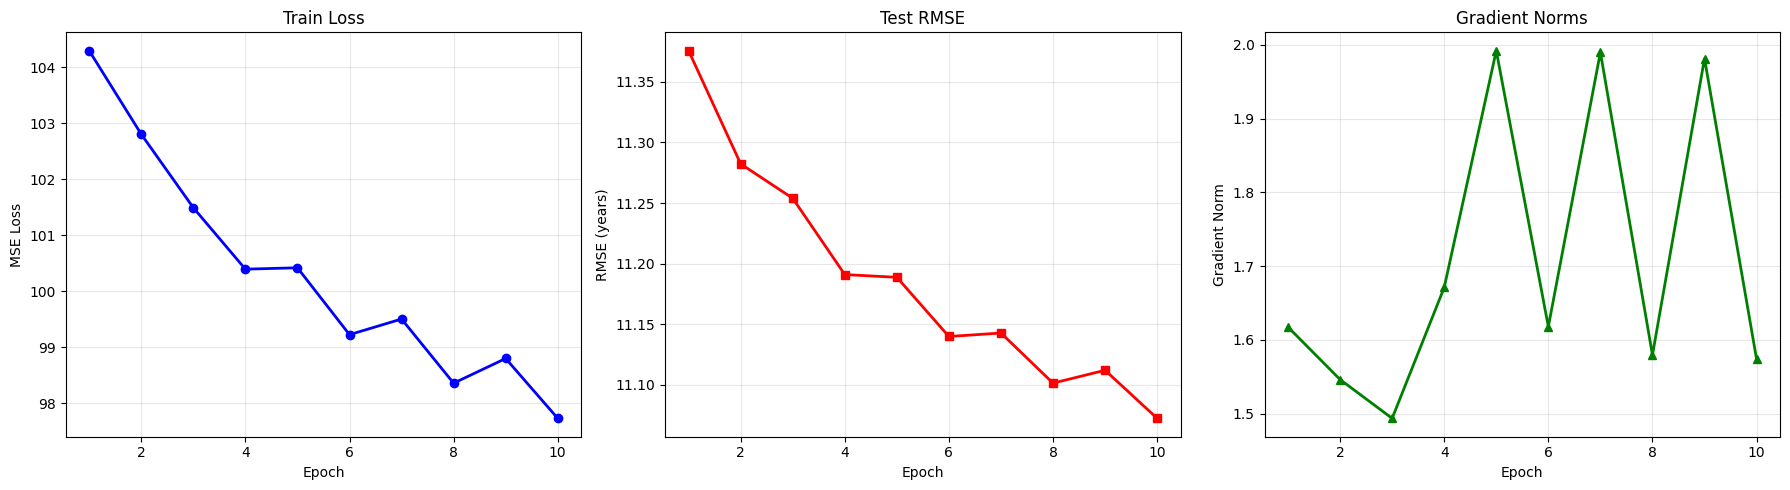

Финальный Test RMSE: 11.07 лет
Улучшение за обучение: 0.30 лет


In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(range(1, epochs + 1), train_losses, marker='o', linewidth=2, color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Train Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, epochs + 1), test_rmses, marker='s', linewidth=2, color='red')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSE (years)')
ax2.set_title('Test RMSE')
ax2.grid(True, alpha=0.3)

ax3.plot(range(1, epochs + 1), gradient_norms, marker='^', linewidth=2, color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Gradient Norm')
ax3.set_title('Gradient Norms')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Финальный Test RMSE: {test_rmses[-1]:.2f} лет")
print(f"Улучшение за обучение: {test_rmses[0] - test_rmses[-1]:.2f} лет")

**В результате получилась рабочая модель, которая показывает себя даже немного лучше (RMSE = 11.07) чем Ridge (RMSE = 10.85) даже только на 10 эпохах! Результат порадовал.**

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

In [19]:
def training_epoch(model, optimizer, criterion, train_loader):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
    """

    # your code here  ♪┏(・o･)┛♪

    raise NotImplementedError


@torch.no_grad()
def validation_epoch(model, criterion, val_loader):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
    """

    # your code here   ฅ^•ﻌ•^ฅ

    raise NotImplementedError


@torch.no_grad()
def predict(model, data_loader):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        criterion - loss function from torch.nn
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        predicts - torch.tensor with shape (len(test_loader.dataset), ),
                   which contains predictions for test objects
    """

    # your code here  =^･ω･^=

    predicts = torch.ones(len(test_loader.dataset))
    return predicts


def train(model, optimizer, criterion, train_loader, val_loader, epochs):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
    """

    # your code here  ¯\_(ツ)_/¯

    raise NotImplementedError





    # эти функции скопированы и дополнены ниже, для удобного последовательного чтения.
    # единственное мое дополнение именно к параметрам - передача device. Это нужно для того,
    # чтобы все точно производилось на одном устройстве и не было ошибок.

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt


# преобразуем годы в классы
unique_years = np.unique(y)
num_classes = len(unique_years)
print(f"Уникальные годы: от {unique_years.min()} до {unique_years.max()}")
print(f"Количество классов: {num_classes}")

# создаем mapping: год -> индекс класса
year_to_class = {year: idx for idx, year in enumerate(unique_years)}
class_to_year = {idx: year for year, idx in year_to_class.items()}

# преобразуем целевые переменные
y_train_class = np.array([year_to_class[year] for year in y_train])
y_test_class = np.array([year_to_class[year] for year in y_test])

print(f"y_train_class: {y_train_class.min()} - {y_train_class.max()}")
print(f"y_test_class: {y_test_class.min()} - {y_test_class.max()}")

print("Чек размеров")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")



Уникальные годы: от 1922 до 2011
Количество классов: 89
y_train_class: 0 - 88
y_test_class: 2 - 87
Чек размеров
X_train: (289881, 90)
y_train: (289881,)
X_test: (128837, 90)
y_test: (128837,)


In [21]:
# (￣ω￣)
train_size = min(X_train.shape[0], len(y_train_class))
test_size = min(X_test.shape[0], len(y_test_class))

print(f"Безопасные размеры: Train {train_size}, Test {test_size}")

X_train_tensor = torch.FloatTensor(X_train[:train_size])
y_train_tensor = torch.LongTensor(y_train_class[:train_size])
X_test_tensor = torch.FloatTensor(X_test[:test_size])
y_test_tensor = torch.LongTensor(y_test_class[:test_size])

print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_test_tensor: {X_test_tensor.shape}")
print(f"y_test_tensor: {y_test_tensor.shape}")


Безопасные размеры: Train 289881, Test 128837
X_train_tensor: torch.Size([289881, 90])
y_train_tensor: torch.Size([289881])
X_test_tensor: torch.Size([128837, 90])
y_test_tensor: torch.Size([128837])


In [22]:
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders созданы:")
print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")


DataLoaders созданы:
Train batches: 4530, Test batches: 2014


In [23]:
# наша прекрасная архитектура ^^ <3 <3 <3
class TwoLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(TwoLayerNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
hidden_dim = 128

model = TwoLayerNet(input_dim, hidden_dim, num_classes)
print(f"Архитектура: {input_dim} -> {hidden_dim} -> {num_classes}")
print(f"Параметров: {sum(p.numel() for p in model.parameters())}")



Архитектура: 90 -> 128 -> 89
Параметров: 23129


In [25]:
def training_epoch(model, optimizer, criterion, train_loader, device):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    total_samples = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        # forward pass
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        # backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
        total_samples += data.size(0)

    return total_loss / total_samples

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, device):
    """Одна эпоха валидации модели"""
    model.eval()
    total_loss = 0
    total_samples = 0

    for data, target in val_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)

        total_loss += loss.item() * data.size(0)
        total_samples += data.size(0)

    return total_loss / total_samples

@torch.no_grad()
def predict(model, data_loader, device):
    """Предсказания модели"""
    model.eval()
    all_predictions = []

    for data, _ in data_loader:
        data = data.to(device)
        output = model(data)
        # берем наиболее вероятный класс
        predictions = torch.argmax(output, dim=1)
        all_predictions.append(predictions.cpu())

    predicts = torch.cat(all_predictions, dim=0)
    return predicts



def train(model, optimizer, criterion, train_loader, val_loader, epochs, device):
    """Обучение модели"""
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        train_loss = training_epoch(model, optimizer, criterion, train_loader, device)
        train_losses.append(train_loss)

        val_loss = validation_epoch(model, criterion, val_loader, device)
        val_losses.append(val_loss)

        print(f'Epoch [{epoch+1}/{epochs}]: '
              f'Train Loss: {train_loss:.4f}, '
              f'Val Loss: {val_loss:.4f}')

    return train_losses, val_losses

def class_to_year_mapping(class_predictions, class_to_year):
    """Преобразует предсказанные классы обратно в годы"""
    years = torch.tensor([class_to_year[cls.item()] for cls in class_predictions])
    return years

def calculate_rmse_from_classes(model, data_loader, true_years, class_to_year, device):
    """Вычисляет RMSE из предсказанных классов"""
    class_predictions = predict(model, data_loader, device)

    predicted_years = class_to_year_mapping(class_predictions, class_to_year)

    if isinstance(true_years, np.ndarray):
        true_years = torch.FloatTensor(true_years[:len(predicted_years)])

    rmse = torch.sqrt(torch.mean((predicted_years - true_years) ** 2))
    return rmse.item(), predicted_years



Теперь запустим обучение:

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}") # проверка

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

epochs = 4

train_losses, val_losses = train(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=epochs,
    device=device
)

test_rmse, test_predictions = calculate_rmse_from_classes(
    model=model,
    data_loader=test_loader,
    true_years=y_test,
    class_to_year=class_to_year,
    device=device
)

print(f"RMSE на тестовой выборке: {test_rmse:.2f} лет")

Используется устройство: cuda
Epoch [1/4]: Train Loss: 4.7953, Val Loss: 4.3516
Epoch [2/4]: Train Loss: 4.2881, Val Loss: 4.2303
Epoch [3/4]: Train Loss: 4.1746, Val Loss: 4.1258
Epoch [4/4]: Train Loss: 4.0778, Val Loss: 4.0367
RMSE на тестовой выборке: 13.81 лет


Посмотрим на результаты:

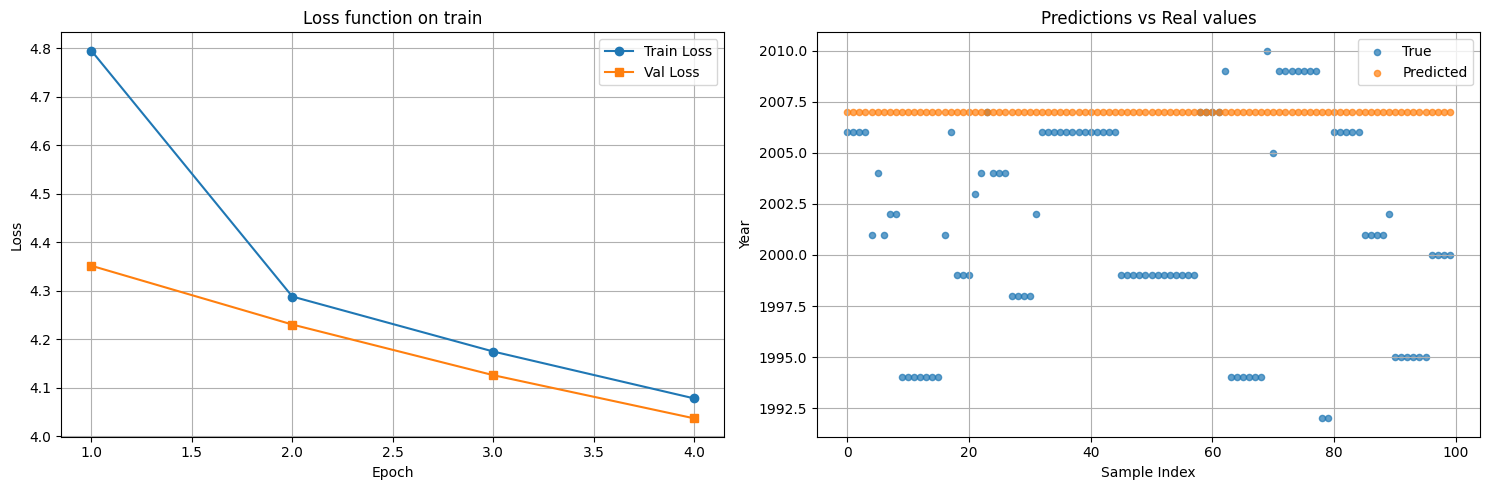

Сравним модели:
Нейронная сеть (классификация): 13.81 лет
Линейная регрессия: 11.07 лет
Ridge регрессия: 9.47 лет
Константное предсказание: 10.85 лет


In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
ax1.plot(range(1, epochs + 1), val_losses, label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss function on train')
ax1.legend()
ax1.grid(True)

sample_size = min(100, len(test_predictions))
ax2.scatter(range(sample_size), y_test[:sample_size], alpha=0.7, label='True', s=20)
ax2.scatter(range(sample_size), test_predictions[:sample_size], alpha=0.7, label='Predicted', s=20)
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Year')
ax2.set_title('Predictions vs Real values')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Сравним модели:")
print(f"Нейронная сеть (классификация): {test_rmse:.2f} лет")
print(f"Линейная регрессия: {test_rmses[-1]:.2f} лет")
print(f"Ridge регрессия: {rmse_for_model:.2f} лет")
print(f"Константное предсказание: {best_rmse_metric:.2f} лет")

**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** данная нейронная сеть (с параметрами из задания) не побила результаты предыдущих решений. Она работает, выдает результаты, но все равно она хуже, чем даже константное предсказание. Можно, конечно, увеличить количество эпох, количество параметров сети, но есть ли в этом смысл? Тем более это даже противоречит здравому смыслу - в задаче предсказания года использовать классификацию. А что если это решение для реального мира? Каждый год выходят новые треки, время идет вперед, соответственно "классов" у такой модели с каждым годом будет больше на 1. Теперь переобучать все это каждый раз? Звучит не очень привлекательно. Поэтому, я считаю, что учить классификатор для этой задачи - не очень хорошая идея.


**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_size = min(X_train.shape[0], len(y_train))
test_size = min(X_test.shape[0], len(y_test))

X_train_tensor = torch.FloatTensor(X_train[:train_size])
y_train_tensor = torch.FloatTensor(y_train[:train_size]).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test[:test_size])
y_test_tensor = torch.FloatTensor(y_test[:test_size]).view(-1, 1)

print(f"Размеры тензоров:")
print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Размеры тензоров:
X_train: torch.Size([289881, 90]), y_train: torch.Size([289881, 1])


In [29]:
@torch.no_grad()
def predict_regression(model, data_loader, device):
    """Предсказания для регрессии"""
    model.eval()
    all_predictions = []

    for data, _ in data_loader:
        data = data.to(device)
        output = model(data)
        all_predictions.append(output.cpu())

    return torch.cat(all_predictions, dim=0)

In [30]:
class RegressionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(RegressionNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
hidden_dim = 128
model = RegressionNet(input_dim, hidden_dim)

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.000000001)

epochs = 4

train_losses, val_losses = train(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=epochs,
    device=device
)

@torch.no_grad()
def calculate_rmse(model, data_loader, true_years, device):
    """Вычисляет RMSE с денормализацией предсказаний"""
    predictions = predict_regression(model, data_loader, device)

    if isinstance(true_years, np.ndarray):
        true_years = torch.FloatTensor(true_years[:len(predictions)])

    rmse = torch.sqrt(torch.mean((predictions.squeeze() - true_years) ** 2))
    return rmse.item(), predictions

test_rmse, test_predictions = calculate_rmse(
    model=model,
    data_loader=test_loader,
    true_years=y_test,
    device=device
)

print(f"RMSE на тестовой выборке: {test_rmse:.2f} лет")

Epoch [1/4]: Train Loss: 501995.1352, Val Loss: 409794.6182
Epoch [2/4]: Train Loss: 385581.4688, Val Loss: 365363.3378
Epoch [3/4]: Train Loss: 350219.4365, Val Loss: 339064.8435
Epoch [4/4]: Train Loss: 324084.8643, Val Loss: 311258.1686
RMSE на тестовой выборке: 557.91 лет


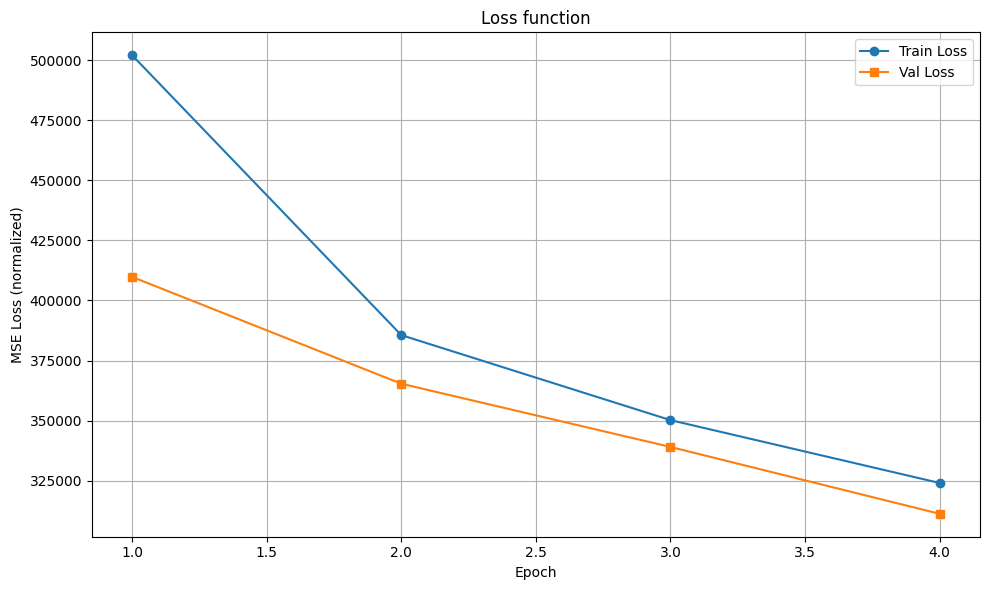

Финальное сравнение:
Нейронная сеть (регрессия): 557.91 лет
Нейронная сеть (классификация): 13.58 лет
Линейная регрессия: 10.83 лет
Ridge регрессия: 9.47 лет


In [32]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Loss function')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Финальное сравнение:")
print(f"Нейронная сеть (регрессия): {test_rmse:.2f} лет")
print(f"Нейронная сеть (классификация): 13.58 лет")
print(f"Линейная регрессия: 10.83 лет")
print(f"Ridge регрессия: {rmse_for_model:.2f} лет")

Сначала я сделала это задание с нормализацией, но потом прочитала задание 8 и поняла, что нужно было это делать без нормализации.:(
Если кратко: нейронная сеть без нормализации практически не обучается. Learning rate я тоже меняла, но это, к сожалению, не помогло добиться качественной рабботы данной нейронной сети.

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** как и ожидалось, в данной задаче обучать регрессию гораздо эффективнее! (спойлер: только если есть нормализация. без неё результата нет.)  Но если сравнивать с, например, результатами на Ridge, то можно сделать вывод, что это не лучшее решение. Но, опять же, здесь гиперпараметры заданы из задания, их можно улучшать и добиться лучшего результата. Посмотрим на распределение целевой переменной и магнитуду значений признаков:

In [33]:
print(f"Годы: {y_train.min()} - {y_train.max()}")
print(f"Диапазон: {y_train.max() - y_train.min()} лет")
print(f"Mean: {y_train.mean():.1f}, Std: {y_train.std():.1f}")

print(f"X_train scaled - Mean: {X_train.mean():.3f}")
print(f"X_train scaled - Std: {X_train.std():.3f}")

Годы: 1922 - 2011
Диапазон: 89 лет
Mean: 1998.4, Std: 10.9
X_train scaled - Mean: 116.145
X_train scaled - Std: 507.773


Из данного анализа видим, что целевая переменная и признаки не нормализированы. Это создает огромные градиенты (из-за дизбаланса масштабов). Уменьшенный lr также не помог решить эту проблему.

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [34]:
target_min = None
target_max = None

def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    global target_min, target_max

    if target_min is None or target_max is None:
        target_min = np.min(sample)
        target_max = np.max(sample)

    if target_max == target_min:
        return np.zeros_like(sample)

    normalized_sample = (sample - target_min) / (target_max - target_min)

    return normalized_sample

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    # ( ⚆ ω ⚆)
    global target_min, target_max

    if target_min is None or target_max is None:
        raise ValueError("Сначала нужно выполнить normalize на обучающей выборке!")

    denormalized_sample = sample * (target_max - target_min) + target_min

    return denormalized_sample

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [39]:
y_train_normalized = normalize(y_train)
y_test_normalized = normalize(y_test)

X_train_tensor = torch.FloatTensor(X_train[:train_size])
y_train_tensor = torch.FloatTensor(y_train_normalized[:train_size]).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test[:test_size])
y_test_tensor = torch.FloatTensor(y_test_normalized[:test_size]).view(-1, 1)

In [40]:
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class RegressionNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(RegressionNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                # Другая инициализация для последнего слоя
                if layer.out_features == 1:
                    nn.init.normal_(layer.weight, mean=0.0, std=0.01)
                else:
                    nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.network(x)

input_dim = X_train.shape[1]
hidden_dim = 128
model = RegressionNet(input_dim, hidden_dim)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

epochs = 4

train_losses, val_losses = train(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=epochs,
    device=device
)



@torch.no_grad()
def calculate_rmse(model, data_loader, true_years_original, device):
    """Вычисляет RMSE с денормализацией предсказаний"""
    predictions_normalized = predict_regression(model, data_loader, device)

    predictions_denormalized_np = denormalize(predictions_normalized.squeeze().numpy())
    predictions_denormalized = torch.FloatTensor(predictions_denormalized_np)

    if isinstance(true_years_original, np.ndarray):
        true_years_original = torch.FloatTensor(true_years_original[:len(predictions_denormalized)])

    if predictions_denormalized.dim() > 1:
        predictions_denormalized = predictions_denormalized.squeeze()

    rmse = torch.sqrt(torch.mean((predictions_denormalized - true_years_original) ** 2))
    return rmse.item(), predictions_denormalized


test_rmse, test_predictions = calculate_rmse(
    model=model,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)


print(f"RMSE на тестовой выборке: {test_rmse:.2f} лет")
print(f"Диапазон предсказаний: {test_predictions.min():.1f} - {test_predictions.max():.1f}")
print(f"Размер предсказаний: {test_predictions.shape}")

Epoch [1/4]: Train Loss: 0.0359, Val Loss: 0.0347
Epoch [2/4]: Train Loss: 0.0353, Val Loss: 0.0347
Epoch [3/4]: Train Loss: 0.0353, Val Loss: 0.0347
Epoch [4/4]: Train Loss: 0.0353, Val Loss: 0.0347
RMSE на тестовой выборке: 16.58 лет
Диапазон предсказаний: 2011.0 - 2011.0
Размер предсказаний: torch.Size([128837])


Может сначала показаться, что диапазон предсказаний странный, но это на самом деле ожидаемо, ведь сигмоида "застревает" на границах. Модель быстро поняла, что предсказывать максимальное значение (2011) дает меньший MSE. Из-за проблемы градиентов не может "отлепиться" от этой границы.
Короче, это даже наоборот показывает то, что сигмоида - не лучший выбор для задачи регрессии.

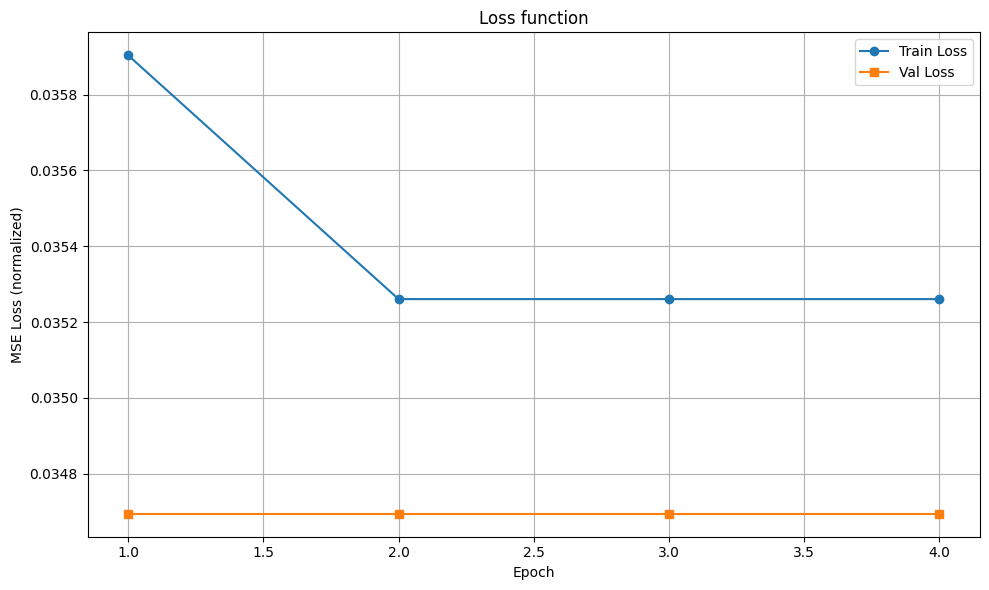

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Loss function')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_normalized = normalize(y_train)
y_test_normalized = normalize(y_test)

X_train_tensor = torch.FloatTensor(X_train_scaled[:train_size])
y_train_tensor = torch.FloatTensor(y_train_normalized[:train_size]).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled[:test_size])
y_test_tensor = torch.FloatTensor(y_test_normalized[:test_size]).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [43]:
input_dim = X_train_scaled.shape[1]
hidden_dim = 128
model = RegressionNet(input_dim, hidden_dim)

In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 20

train_losses, val_losses = train(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=epochs,
    device=device
)

Epoch [1/20]: Train Loss: 0.0128, Val Loss: 0.0114
Epoch [2/20]: Train Loss: 0.0113, Val Loss: 0.0109
Epoch [3/20]: Train Loss: 0.0109, Val Loss: 0.0106
Epoch [4/20]: Train Loss: 0.0106, Val Loss: 0.0105
Epoch [5/20]: Train Loss: 0.0105, Val Loss: 0.0103
Epoch [6/20]: Train Loss: 0.0104, Val Loss: 0.0103
Epoch [7/20]: Train Loss: 0.0103, Val Loss: 0.0102
Epoch [8/20]: Train Loss: 0.0102, Val Loss: 0.0101
Epoch [9/20]: Train Loss: 0.0102, Val Loss: 0.0101
Epoch [10/20]: Train Loss: 0.0101, Val Loss: 0.0101
Epoch [11/20]: Train Loss: 0.0101, Val Loss: 0.0101
Epoch [12/20]: Train Loss: 0.0101, Val Loss: 0.0100
Epoch [13/20]: Train Loss: 0.0100, Val Loss: 0.0100
Epoch [14/20]: Train Loss: 0.0100, Val Loss: 0.0100
Epoch [15/20]: Train Loss: 0.0100, Val Loss: 0.0100
Epoch [16/20]: Train Loss: 0.0100, Val Loss: 0.0100
Epoch [17/20]: Train Loss: 0.0100, Val Loss: 0.0100
Epoch [18/20]: Train Loss: 0.0099, Val Loss: 0.0100
Epoch [19/20]: Train Loss: 0.0099, Val Loss: 0.0100
Epoch [20/20]: Train 

In [45]:
test_rmse, test_predictions = calculate_rmse(
    model=model,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

print(f"RMSE на тестовой выборке: {test_rmse:.2f} лет")
print(f"Диапазон предсказаний: {test_predictions.min():.1f} - {test_predictions.max():.1f}")

RMSE на тестовой выборке: 8.88 лет
Диапазон предсказаний: 1961.1 - 2011.0


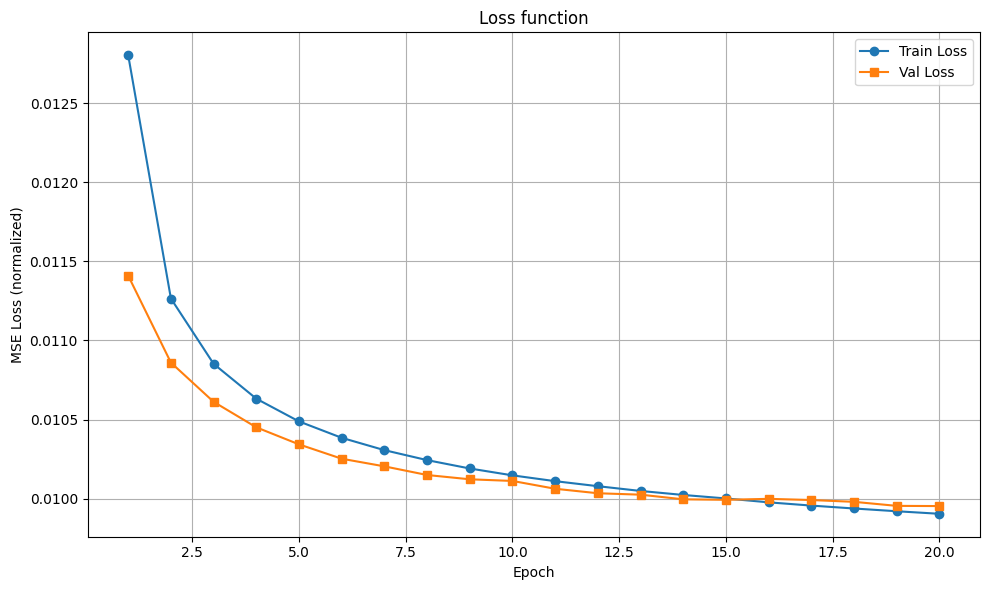

In [46]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, epochs + 1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Loss function')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

In [ ]:
Да, данный вариант уже работает лучше. Так, получены были результаты:
10 эпох, lr = 0.001 -> 10.31
20 эпох, lr = 0.001 -> 10.11
20 эпох, lr = 0.0001 -> 11.05
10 эпох, lr = 0.01 -> 9.49
10 эпох, lr = 0.1 -> 8.94
10 эпох, lr = 1 -> 8.82
20 эпох, lr = 0.1 -> 8.88

Такое качество действительно сравнимо с Ridge регрессией.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

In [47]:
# ( ཀ ʖ̯ ཀ)
model_sgd_momentum = RegressionNet(input_dim, hidden_dim)
model_sgd_momentum = model_sgd_momentum.to(device)

optimizer_sgd_momentum = optim.SGD(model_sgd_momentum.parameters(), lr=0.01, momentum=0.9)
criterion = nn.MSELoss()

print("Обучаем SGD+momentum...")
train_losses_sgd_m, val_losses_sgd_m = train(
    model=model_sgd_momentum,
    optimizer=optimizer_sgd_momentum,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=10,
    device=device
)

test_rmse_sgd_m, test_predictions_sgd_m = calculate_rmse(
    model=model_sgd_momentum,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

Обучаем SGD+momentum...
Epoch [1/10]: Train Loss: 0.0130, Val Loss: 0.0114
Epoch [2/10]: Train Loss: 0.0113, Val Loss: 0.0109
Epoch [3/10]: Train Loss: 0.0109, Val Loss: 0.0107
Epoch [4/10]: Train Loss: 0.0107, Val Loss: 0.0105
Epoch [5/10]: Train Loss: 0.0106, Val Loss: 0.0104
Epoch [6/10]: Train Loss: 0.0105, Val Loss: 0.0103
Epoch [7/10]: Train Loss: 0.0104, Val Loss: 0.0103
Epoch [8/10]: Train Loss: 0.0103, Val Loss: 0.0102
Epoch [9/10]: Train Loss: 0.0102, Val Loss: 0.0102
Epoch [10/10]: Train Loss: 0.0102, Val Loss: 0.0101


In [48]:
model_adam = RegressionNet(input_dim, hidden_dim)
model_adam = model_adam.to(device)

optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Обучаем Adam...")
train_losses_adam, val_losses_adam = train(
    model=model_adam,
    optimizer=optimizer_adam,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=10,
    device=device
)

test_rmse_adam, test_predictions_adam = calculate_rmse(
    model=model_adam,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

Обучаем Adam...
Epoch [1/10]: Train Loss: 0.0113, Val Loss: 0.0101
Epoch [2/10]: Train Loss: 0.0101, Val Loss: 0.0100
Epoch [3/10]: Train Loss: 0.0098, Val Loss: 0.0098
Epoch [4/10]: Train Loss: 0.0097, Val Loss: 0.0099
Epoch [5/10]: Train Loss: 0.0097, Val Loss: 0.0098
Epoch [6/10]: Train Loss: 0.0096, Val Loss: 0.0099
Epoch [7/10]: Train Loss: 0.0095, Val Loss: 0.0099
Epoch [8/10]: Train Loss: 0.0095, Val Loss: 0.0098
Epoch [9/10]: Train Loss: 0.0094, Val Loss: 0.0098
Epoch [10/10]: Train Loss: 0.0094, Val Loss: 0.0099


СРАВНЕНИЕ ОПТИМИЗАТОРОВ:
SGD+momentum: 8.96 лет
Adam:         8.85 лет
Обычный SGD:  8.88 лет
Ridge:        9.47 лет


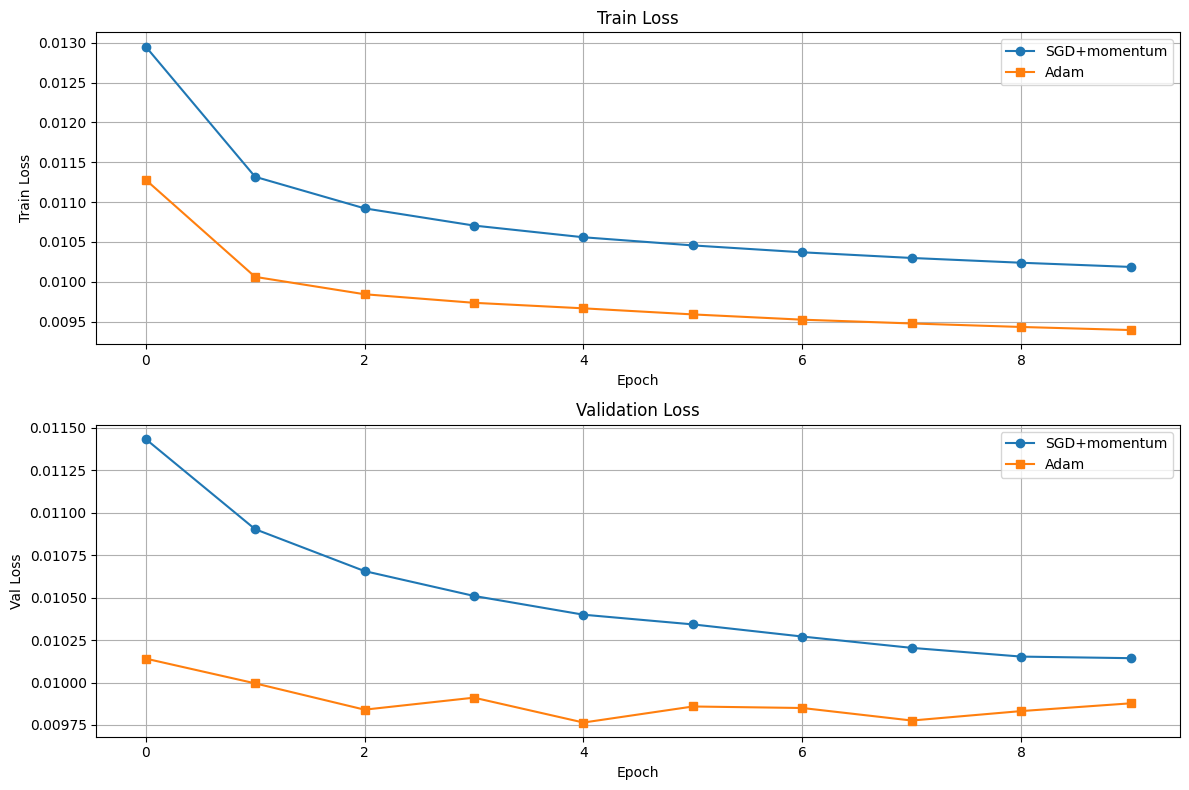

In [49]:
print("=" * 50)
print("СРАВНЕНИЕ ОПТИМИЗАТОРОВ:")
print("=" * 50)
print(f"SGD+momentum: {test_rmse_sgd_m:.2f} лет")
print(f"Adam:         {test_rmse_adam:.2f} лет")
print(f"Обычный SGD:  {test_rmse:.2f} лет")  # из предыдущего эксперимента
print(f"Ridge:        9.47 лет")

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(train_losses_sgd_m, label='SGD+momentum', marker='o')
plt.plot(train_losses_adam, label='Adam', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Train Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(val_losses_sgd_m, label='SGD+momentum', marker='o')
plt.plot(val_losses_adam, label='Adam', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Adam проявил себя лучше всех (8.85), значит, буду использовать его.

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

In [50]:
# (๑-﹏-๑)
class DeepWideNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super(DeepWideNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),

            # добавляем еще один скрытый слой
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),

            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
hidden_dim1 = 128 * 3
hidden_dim2 = 128

model_deep_wide = DeepWideNet(input_dim, hidden_dim1, hidden_dim2)
print(f"Архитектура: {input_dim} -> {hidden_dim1} -> {hidden_dim2} -> 1")
print(f"Параметров: {sum(p.numel() for p in model_deep_wide.parameters())}")

Архитектура: 90 -> 384 -> 128 -> 1
Параметров: 84353


In [51]:
model_deep_wide = model_deep_wide.to(device)

optimizer_adam = optim.Adam(model_deep_wide.parameters(), lr=0.001)
criterion = nn.MSELoss()

epochs = 10

train_losses_deep, val_losses_deep = train(
    model=model_deep_wide,
    optimizer=optimizer_adam,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=epochs,
    device=device
)

Epoch [1/10]: Train Loss: 0.0106, Val Loss: 0.0100
Epoch [2/10]: Train Loss: 0.0097, Val Loss: 0.0097
Epoch [3/10]: Train Loss: 0.0095, Val Loss: 0.0097
Epoch [4/10]: Train Loss: 0.0092, Val Loss: 0.0097
Epoch [5/10]: Train Loss: 0.0090, Val Loss: 0.0096
Epoch [6/10]: Train Loss: 0.0087, Val Loss: 0.0097
Epoch [7/10]: Train Loss: 0.0085, Val Loss: 0.0098
Epoch [8/10]: Train Loss: 0.0083, Val Loss: 0.0099
Epoch [9/10]: Train Loss: 0.0080, Val Loss: 0.0100
Epoch [10/10]: Train Loss: 0.0078, Val Loss: 0.0101


In [52]:
test_rmse_deep, test_predictions_deep = calculate_rmse(
    model=model_deep_wide,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

print("=" * 60)
print("СРАВНЕНИЕ АРХИТЕКТУР:")
print("=" * 60)
print(f"Простая сеть (128):          {test_rmse_adam:.2f} лет")  # из предыдущего
print(f"Глубокая и широкая сеть:     {test_rmse_deep:.2f} лет")
print(f"Ridge:                       9.47 лет")
print(f"Улучшение:                   {test_rmse_adam - test_rmse_deep:.2f} лет")

СРАВНЕНИЕ АРХИТЕКТУР:
Простая сеть (128):          8.85 лет
Глубокая и широкая сеть:     8.97 лет
Ridge:                       9.47 лет
Улучшение:                   -0.12 лет


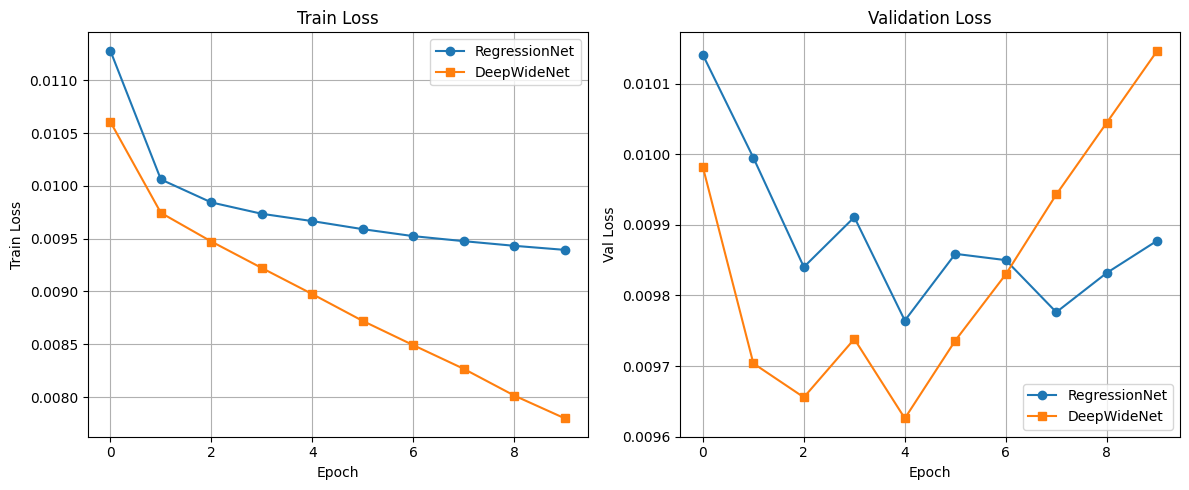

In [53]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_adam, label='RegressionNet', marker='o')
plt.plot(train_losses_deep, label='DeepWideNet', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Train Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_losses_adam, label='RegressionNet', marker='o')
plt.plot(val_losses_deep, label='DeepWideNet', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ при добавлении одного слоя и расширении первого слоя в 2 раза качество 8.99. При увеличении слоя в 3 раза качество 8.97. Да, казалось бы, лучше, НО! На самом деле уже происходит переобучение. Это явно видно на графике выше справа (лосс на валидации). После шестой эпохи (даже на пятой) видно, что val loss растет, что как раз и указывает на переобучение.

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

In [99]:
# (❍ᴥ❍ʋ)
class DeepWideNet_Dropout(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.2):
        super(DeepWideNet_Dropout, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.network(x)

model_dropout = DeepWideNet_Dropout(input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.2)

In [55]:
class DeepWideNet_BN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2):
        super(DeepWideNet_BN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.BatchNorm1d(hidden_dim1),
            nn.ReLU(),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.BatchNorm1d(hidden_dim2),
            nn.ReLU(),

            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.network(x)

model_bn = DeepWideNet_BN(input_dim, hidden_dim1, hidden_dim2)

In [56]:
print("Обучаем модель с Dropout (p=0.2)...")
model_dropout = model_dropout.to(device)
optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=0.001)

train_losses_dropout, val_losses_dropout = train(
    model=model_dropout,
    optimizer=optimizer_dropout,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=10,
    device=device
)

Обучаем модель с Dropout (p=0.2)...
Epoch [1/10]: Train Loss: 0.0112, Val Loss: 0.0101
Epoch [2/10]: Train Loss: 0.0101, Val Loss: 0.0098
Epoch [3/10]: Train Loss: 0.0099, Val Loss: 0.0096
Epoch [4/10]: Train Loss: 0.0097, Val Loss: 0.0096
Epoch [5/10]: Train Loss: 0.0096, Val Loss: 0.0097
Epoch [6/10]: Train Loss: 0.0095, Val Loss: 0.0096
Epoch [7/10]: Train Loss: 0.0094, Val Loss: 0.0095
Epoch [8/10]: Train Loss: 0.0093, Val Loss: 0.0096
Epoch [9/10]: Train Loss: 0.0092, Val Loss: 0.0097
Epoch [10/10]: Train Loss: 0.0091, Val Loss: 0.0095


In [57]:
print("Обучаем модель с Batch Normalization...")
model_bn = model_bn.to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)

train_losses_bn, val_losses_bn = train(
    model=model_bn,
    optimizer=optimizer_bn,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=10,
    device=device
)

Обучаем модель с Batch Normalization...
Epoch [1/10]: Train Loss: 0.0109, Val Loss: 0.0099
Epoch [2/10]: Train Loss: 0.0099, Val Loss: 0.0097
Epoch [3/10]: Train Loss: 0.0096, Val Loss: 0.0096
Epoch [4/10]: Train Loss: 0.0094, Val Loss: 0.0096
Epoch [5/10]: Train Loss: 0.0092, Val Loss: 0.0096
Epoch [6/10]: Train Loss: 0.0090, Val Loss: 0.0095
Epoch [7/10]: Train Loss: 0.0089, Val Loss: 0.0096
Epoch [8/10]: Train Loss: 0.0087, Val Loss: 0.0095
Epoch [9/10]: Train Loss: 0.0085, Val Loss: 0.0098
Epoch [10/10]: Train Loss: 0.0084, Val Loss: 0.0097


In [58]:
test_rmse_dropout, _ = calculate_rmse(
    model=model_dropout,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

test_rmse_bn, _ = calculate_rmse(
    model=model_bn,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

print("=" * 70)
print("СРАВНЕНИЕ МЕТОДОВ РЕГУЛЯРИЗАЦИИ:")
print("=" * 70)
print(f"Базовая глубокая сеть:      {test_rmse_deep:.2f} лет")
print(f"С Dropout (p=0.2):         {test_rmse_dropout:.2f} лет")
print(f"С Batch Normalization:     {test_rmse_bn:.2f} лет")
print(f"Ridge:                     9.47 лет")

СРАВНЕНИЕ МЕТОДОВ РЕГУЛЯРИЗАЦИИ:
Базовая глубокая сеть:      8.97 лет
С Dropout (p=0.2):         8.68 лет
С Batch Normalization:     8.75 лет
Ridge:                     9.47 лет


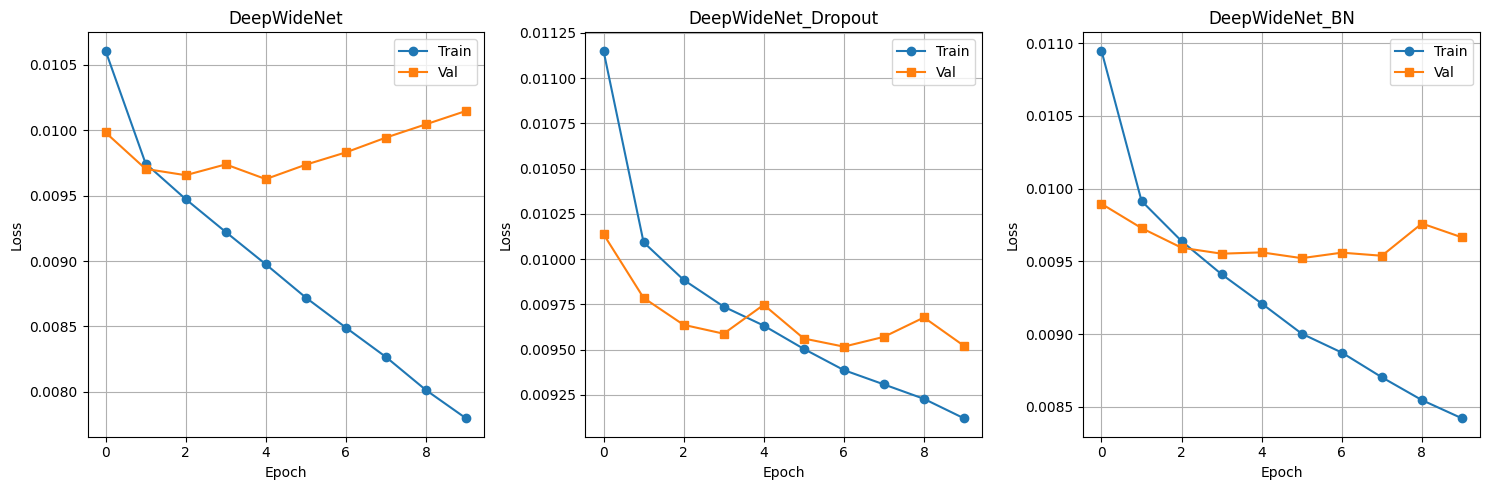

In [59]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses_deep, label='Train', marker='o')
plt.plot(val_losses_deep, label='Val', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DeepWideNet')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(train_losses_dropout, label='Train', marker='o')
plt.plot(val_losses_dropout, label='Val', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DeepWideNet_Dropout')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(train_losses_bn, label='Train', marker='o')
plt.plot(val_losses_bn, label='Val', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DeepWideNet_BN')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ данные эксперименты показали, что dropout и batch normalization действительно помогают бороться с переобучением, только Dropout это делает лучше. У Batch Normalization переобучение видно уже после 3 эпохи, у дропаута - только после 5 эпохи. Конечно, val loss у дропаута тоже не идеальный (убывает не равномерно, со скачками), но это в любом случае лучше, чем исходная сеть и Batch Norm.

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [100]:
# (｡❤‿❤｡)
# запишем финальный вариант нейронной сети после всех экспериментов
class FinalNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, dropout_rate=0.3):
        super(FinalNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim2, 1),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        return self.network(x)

input_dim = X_train_scaled.shape[1]
hidden_dim1 = 384
hidden_dim2 = 128

In [69]:
learning_rates = [1e-4, 3e-4, 1e-3, 3e-3]
lr_results = []

print("=" * 50)
print("ПОИСК ОПТИМАЛЬНОГО LEARNING RATE")
print("=" * 50)

for lr in learning_rates:
    print(f"\nТестируем LR = {lr}")

    model = FinalNet(input_dim, hidden_dim1, hidden_dim2)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, fused=True)

    train_losses, val_losses = train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=test_loader,
        epochs=8,
        device=device
    )

    test_rmse, _ = calculate_rmse(
        model=model,
        data_loader=test_loader,
        true_years_original=y_test,
        device=device
    )

    lr_results.append({
        'lr': lr,
        'train_loss': train_losses[-1],
        'val_loss': val_losses[-1],
        'test_rmse': test_rmse
    })

    print(f"LR {lr}: RMSE = {test_rmse:.2f} лет")

best_lr = min(lr_results, key=lambda x: x['test_rmse'])
print(f"\n🎯 ЛУЧШИЙ LR: {best_lr['lr']} (RMSE = {best_lr['test_rmse']:.2f} лет)")

ПОИСК ОПТИМАЛЬНОГО LEARNING RATE

Тестируем LR = 0.0001
Epoch [1/8]: Train Loss: 0.0134, Val Loss: 0.0108
Epoch [2/8]: Train Loss: 0.0112, Val Loss: 0.0103
Epoch [3/8]: Train Loss: 0.0107, Val Loss: 0.0101
Epoch [4/8]: Train Loss: 0.0104, Val Loss: 0.0098
Epoch [5/8]: Train Loss: 0.0102, Val Loss: 0.0099
Epoch [6/8]: Train Loss: 0.0101, Val Loss: 0.0098
Epoch [7/8]: Train Loss: 0.0100, Val Loss: 0.0097
Epoch [8/8]: Train Loss: 0.0099, Val Loss: 0.0097
LR 0.0001: RMSE = 8.75 лет

Тестируем LR = 0.0003
Epoch [1/8]: Train Loss: 0.0122, Val Loss: 0.0102
Epoch [2/8]: Train Loss: 0.0105, Val Loss: 0.0098
Epoch [3/8]: Train Loss: 0.0102, Val Loss: 0.0098
Epoch [4/8]: Train Loss: 0.0100, Val Loss: 0.0097
Epoch [5/8]: Train Loss: 0.0098, Val Loss: 0.0096
Epoch [6/8]: Train Loss: 0.0097, Val Loss: 0.0096
Epoch [7/8]: Train Loss: 0.0096, Val Loss: 0.0096
Epoch [8/8]: Train Loss: 0.0095, Val Loss: 0.0096
LR 0.0003: RMSE = 8.71 лет

Тестируем LR = 0.001
Epoch [1/8]: Train Loss: 0.0114, Val Loss: 0.

In [70]:
weight_decays = [0, 1e-3]
wd_results = []

print("\n" + "=" * 50)
print("ПОИСК ОПТИМАЛЬНОГО ")
print("=" * 50)

best_lr_value = best_lr['lr']

for wd in weight_decays:
    print(f"\nТестируем Weight Decay = {wd}")

    model = FinalNet(input_dim, hidden_dim1, hidden_dim2)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=best_lr_value, weight_decay=wd)

    train_losses, val_losses = train(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        train_loader=train_loader,
        val_loader=test_loader,
        epochs=8,
        device=device
    )

    test_rmse, _ = calculate_rmse(
        model=model,
        data_loader=test_loader,
        true_years_original=y_test,
        device=device
    )

    wd_results.append({
        'wd': wd,
        'train_loss': train_losses[-1],
        'val_loss': val_losses[-1],
        'test_rmse': test_rmse
    })

    print(f"WD {wd}: RMSE = {test_rmse:.2f} лет")

best_wd = min(wd_results, key=lambda x: x['test_rmse'])
print(f"\n🎯 ЛУЧШИЙ Weight Decay: {best_wd['wd']} (RMSE = {best_wd['test_rmse']:.2f} лет)")


ПОИСК ОПТИМАЛЬНОГО WEIGHT DECAY

Тестируем Weight Decay = 0
Epoch [1/8]: Train Loss: 0.0112, Val Loss: 0.0099
Epoch [2/8]: Train Loss: 0.0102, Val Loss: 0.0098
Epoch [3/8]: Train Loss: 0.0100, Val Loss: 0.0097
Epoch [4/8]: Train Loss: 0.0099, Val Loss: 0.0096
Epoch [5/8]: Train Loss: 0.0098, Val Loss: 0.0096
Epoch [6/8]: Train Loss: 0.0097, Val Loss: 0.0096
Epoch [7/8]: Train Loss: 0.0097, Val Loss: 0.0096
Epoch [8/8]: Train Loss: 0.0096, Val Loss: 0.0095
WD 0: RMSE = 8.70 лет

Тестируем Weight Decay = 0.001
Epoch [1/8]: Train Loss: 0.0116, Val Loss: 0.0107
Epoch [2/8]: Train Loss: 0.0112, Val Loss: 0.0107
Epoch [3/8]: Train Loss: 0.0112, Val Loss: 0.0107
Epoch [4/8]: Train Loss: 0.0112, Val Loss: 0.0106
Epoch [5/8]: Train Loss: 0.0112, Val Loss: 0.0107
Epoch [6/8]: Train Loss: 0.0112, Val Loss: 0.0107
Epoch [7/8]: Train Loss: 0.0112, Val Loss: 0.0108
Epoch [8/8]: Train Loss: 0.0112, Val Loss: 0.0108
WD 0.001: RMSE = 9.23 лет

🎯 ЛУЧШИЙ Weight Decay: 0 (RMSE = 8.70 лет)


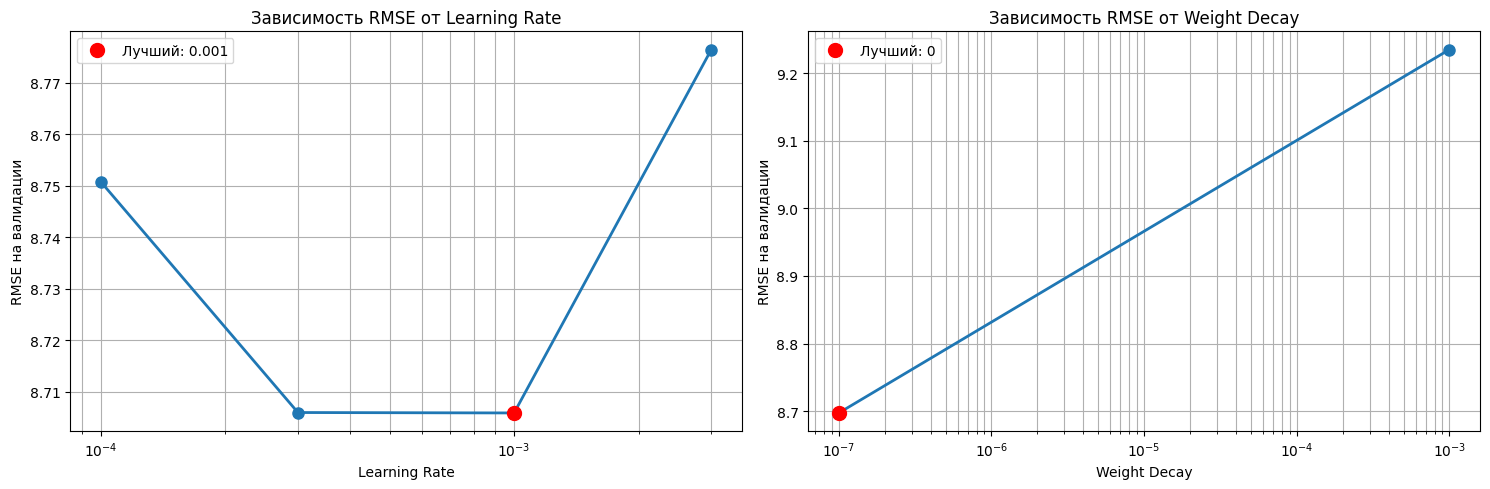

In [71]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
lrs = [x['lr'] for x in lr_results]
rmses = [x['test_rmse'] for x in lr_results]
plt.semilogx(lrs, rmses, 'o-', linewidth=2, markersize=8)
plt.xlabel('Learning Rate')
plt.ylabel('RMSE на валидации')
plt.title('Зависимость RMSE от Learning Rate')
plt.grid(True, which="both", ls="-")

best_idx = lrs.index(best_lr['lr'])
plt.plot(lrs[best_idx], rmses[best_idx], 'ro', markersize=10, label=f'Лучший: {best_lr["lr"]}')
plt.legend()

plt.subplot(1, 2, 2)
wds = [x['wd'] for x in wd_results]
rmses_wd = [x['test_rmse'] for x in wd_results]
plt.semilogx([wd if wd != 0 else 1e-7 for wd in wds], rmses_wd, 'o-', linewidth=2, markersize=8)
plt.xlabel('Weight Decay')
plt.ylabel('RMSE на валидации')
plt.title('Зависимость RMSE от Weight Decay')
plt.grid(True, which="both", ls="-")

best_wd_idx = wds.index(best_wd['wd'])
plt.plot(wds[best_wd_idx] if best_wd['wd'] != 0 else 1e-7, rmses_wd[best_wd_idx], 'ro', markersize=10, label=f'Лучший: {best_wd["wd"]}')
plt.legend()

plt.tight_layout()
plt.show()

In [72]:
print("=" * 60)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ")
print("=" * 60)
print(f"Оптимальный Learning Rate: {best_lr['lr']}")
print(f"Оптимальный Weight Decay: {best_wd['wd']}")
print(f"Лучший RMSE: {best_wd['test_rmse']:.2f} лет")

print(f"\nСравнение с предыдущими результатами:")
print(f"Нейросеть (с гиперпараметрами): {best_wd['test_rmse']:.2f} лет")
print(f"Ridge регрессия:                 9.47 лет")
print(f"Улучшение:                       {9.47 - best_wd['test_rmse']:.2f} лет")

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ
Оптимальный Learning Rate: 0.001
Оптимальный Weight Decay: 0
Лучший RMSE: 8.70 лет

Сравнение с предыдущими результатами:
Нейросеть (с гиперпараметрами): 8.70 лет
Ridge регрессия:                 9.47 лет
Улучшение:                       0.77 лет


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ в результате экспериментов удалось достичь, на мой взгляд, очень хороших результатов! Так, лучший RMSE равен 8.7, что гораздо лучше, чем Ridge и все другие предыдущие варианты нейронной сети. Такой результат был достигнут благодаря усложнению архитектуры (не супер-сильного, чтобы не увязнуть в переобучении), использованию Dropout, Adam оптимизатора, специально подобранного learning rate и weight decay.

> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

Уже полученный результат на предыдущих шагах в целом удовлетворяет указанным в 13 задании требованиям, но хочу все-такии поупражняться с некоторыми предложенными трюками.

In [101]:
# ༼ つ ಥ_ಥ ༽つ
def train_with_early_stopping(model, optimizer, criterion, train_loader, val_loader, epochs, device, patience=5):
    model.to(device)
    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * data.size(0)

        train_loss = total_train_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                total_val_loss += loss.item() * data.size(0)

        val_loss = total_val_loss / len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f'Epoch [{epoch+1}/{epochs}]: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
            print(f'Улучшение!')
        else:
            epochs_no_improve += 1
            print(f'Нет улучшения {epochs_no_improve}/{patience}')

        if epochs_no_improve >= patience:
            print(f'Останавливаемся на эпохе {epoch+1}')
            break

    model.load_state_dict(best_model_state)
    return train_losses, val_losses


In [112]:
model = FinalNet(input_dim, hidden_dim1, hidden_dim2)
model = model.to(device)

In [113]:
model

FinalNet(
  (network): Sequential(
    (0): Linear(in_features=90, out_features=384, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=384, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

In [114]:
# Возвращаемся к РАБОТАЮЩИМ гиперпараметрам
optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

In [115]:
train_losses, val_losses = train_with_early_stopping(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=10,
    device=device,
    patience=3
)

Epoch [1/10]: Train Loss: 0.0113, Val Loss: 0.0100
Улучшение!
Epoch [2/10]: Train Loss: 0.0102, Val Loss: 0.0098
Улучшение!
Epoch [3/10]: Train Loss: 0.0100, Val Loss: 0.0097
Улучшение!
Epoch [4/10]: Train Loss: 0.0099, Val Loss: 0.0096
Улучшение!
Epoch [5/10]: Train Loss: 0.0098, Val Loss: 0.0098
Нет улучшения 1/3
Epoch [6/10]: Train Loss: 0.0097, Val Loss: 0.0096
Улучшение!
Epoch [7/10]: Train Loss: 0.0097, Val Loss: 0.0096
Улучшение!
Epoch [8/10]: Train Loss: 0.0096, Val Loss: 0.0096
Нет улучшения 1/3
Epoch [9/10]: Train Loss: 0.0095, Val Loss: 0.0094
Улучшение!
Epoch [10/10]: Train Loss: 0.0094, Val Loss: 0.0095
Нет улучшения 1/3


In [116]:
test_rmse, test_predictions = calculate_rmse(
    model=model,
    data_loader=test_loader,
    true_years_original=y_test,
    device=device
)

print(f"RMSE с Early Stopping: {test_rmse:.2f} лет")

RMSE с Early Stopping: 8.69 лет


Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__ эксперименты показывают и доказывают, что знание теории нейронных сетей очень важно при работе с ними. Так, даже при одной и той же архитектуре можно получить абсолютно разное качество, что доказало, что крайне важно уделять должное внимание подбору гиперпараметров.

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?


```
───▐▀▄──────▄▀▌───▄▄▄▄▄▄▄
───▌▒▒▀▄▄▄▄▀▒▒▐▄▀▀▒██▒██▒▀▀▄
──▐▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▀▄
──▌▒▒▒▒▒▒▒▒▒▒▒▒▒▄▒▒▒▒▒▒▒▒▒▒▒▒▒▀▄
▀█▒▒█▌▒▒█▒▒▐█▒▒▀▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▌
▀▌▒▒▒▒▒▀▒▀▒▒▒▒▒▀▀▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▐ ▄▄
▐▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▄█▒█
▐▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒█▀
──▐▄▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▒▄▌
────▀▄▄▀▀▀▀▄▄▀▀▀▀▀▀▄▄▀▀▀▀▀▀▄▄▀
```
--------------------------------------------------
Эмоция: чувство, когда прошел на мобильность
